In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [35]:
db_url = 'https://raw.githubusercontent.com/deepakorani/Energy-Efficiency/master/ENB2012_data.csv'

# carregando os dados do csv na var df. 
# Optei por nao colocar baixar os dados e carregá-los pelo caminho relativo pois fazendo assim 
# da para usar algo como o google colab
df = pd.read_csv(db_url)

In [36]:
# Podemos visualizar as primeiras linhas do DF com o metodo head()
display(df.head())

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2,Unnamed: 10,Unnamed: 11
0,0.98,514.5,294.0,110.25,7.0,2.0,0.0,0.0,15.55,21.33,NaN,NaN
1,0.98,514.5,294.0,110.25,7.0,3.0,0.0,0.0,15.55,21.33,NaN,NaN
2,0.98,514.5,294.0,110.25,7.0,4.0,0.0,0.0,15.55,21.33,NaN,NaN
3,0.98,514.5,294.0,110.25,7.0,5.0,0.0,0.0,15.55,21.33,NaN,NaN
4,0.90,563.5,318.5,122.50,7.0,2.0,0.0,0.0,20.84,28.28,NaN,NaN


Podemos prosseguir sem atribuir numeros as colunas, pois isso é somente uma interpretação semântica humana. No entanto, para legibilidade, podemos renomear as colunas para podermos visualizar melhor os dados

Alem disso, veja que temos as colunas "Unnamed: 10" e "Unnamed: 11" que parecem conter apenas valores do tipo NaN. Podemos verificar isso

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1296 entries, 0 to 1295
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   X1           768 non-null    float64
 1   X2           768 non-null    float64
 2   X3           768 non-null    float64
 3   X4           768 non-null    float64
 4   X5           768 non-null    float64
 5   X6           768 non-null    float64
 6   X7           768 non-null    float64
 7   X8           768 non-null    float64
 8   Y1           768 non-null    float64
 9   Y2           768 non-null    float64
 10  Unnamed: 10  0 non-null      float64
 11  Unnamed: 11  0 non-null      float64
dtypes: float64(12)
memory usage: 121.6 KB


Então, podemos remover essas colunas, ou só selecionar as primeiras 10 colunas. 

In [38]:
# Removendo as colunas inuteis
df = df.iloc[:, 0:10]

In [39]:
# testando
df.info()
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 1296 entries, 0 to 1295
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    float64
 6   X7      768 non-null    float64
 7   X8      768 non-null    float64
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(10)
memory usage: 101.4 KB


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2.0,0.0,0.0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3.0,0.0,0.0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4.0,0.0,0.0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5.0,0.0,0.0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2.0,0.0,0.0,20.84,28.28


In [40]:
# Renomeando as colunas

colunas = {
    'X1': 'compacidade_relativa',
    'X2': 'area_superficie',
    'X3': 'area_parede',
    'X4': 'area_telhado',
    'X5': 'altura_total',
    'X6': 'orientacao',
    'X7': 'area_envidracada',
    'X8': 'distrib_area_envidracada',
    'Y1': 'carga_aquecimento', # Target 1
    'Y2': 'carga_resfriamento' # Target 2
}
df = df.rename(columns=colunas)

In [41]:
df = df.dropna()

In [42]:
display(df.head())

,compacidade_relativa,area_superficie,area_parede,area_telhado,altura_total,orientacao,area_envidracada,distrib_area_envidracada,carga_aquecimento,carga_resfriamento
0,0.98,514.5,294.0,110.25,7.0,2.0,0.0,0.0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3.0,0.0,0.0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4.0,0.0,0.0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5.0,0.0,0.0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2.0,0.0,0.0,20.84,28.28


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   compacidade_relativa      768 non-null    float64
 1   area_superficie           768 non-null    float64
 2   area_parede               768 non-null    float64
 3   area_telhado              768 non-null    float64
 4   altura_total              768 non-null    float64
 5   orientacao                768 non-null    float64
 6   area_envidracada          768 non-null    float64
 7   distrib_area_envidracada  768 non-null    float64
 8   carga_aquecimento         768 non-null    float64
 9   carga_resfriamento        768 non-null    float64
dtypes: float64(10)
memory usage: 60.1 KB


In [44]:
# Vamos fazer a regressão no Y1 primeiro, pra isso, podemos remover o Y2. 

df = df.drop(columns=['carga_resfriamento'])

print("Dimensões do dataset:", df.shape)
display(df.head())

Dimensões do dataset: (768, 9)


,compacidade_relativa,area_superficie,area_parede,area_telhado,altura_total,orientacao,area_envidracada,distrib_area_envidracada,carga_aquecimento
0,0.98,514.5,294.0,110.25,7.0,2.0,0.0,0.0,15.55
1,0.98,514.5,294.0,110.25,7.0,3.0,0.0,0.0,15.55
2,0.98,514.5,294.0,110.25,7.0,4.0,0.0,0.0,15.55
3,0.98,514.5,294.0,110.25,7.0,5.0,0.0,0.0,15.55
4,0.90,563.5,318.5,122.50,7.0,2.0,0.0,0.0,20.84


In [45]:
import seaborn as sns

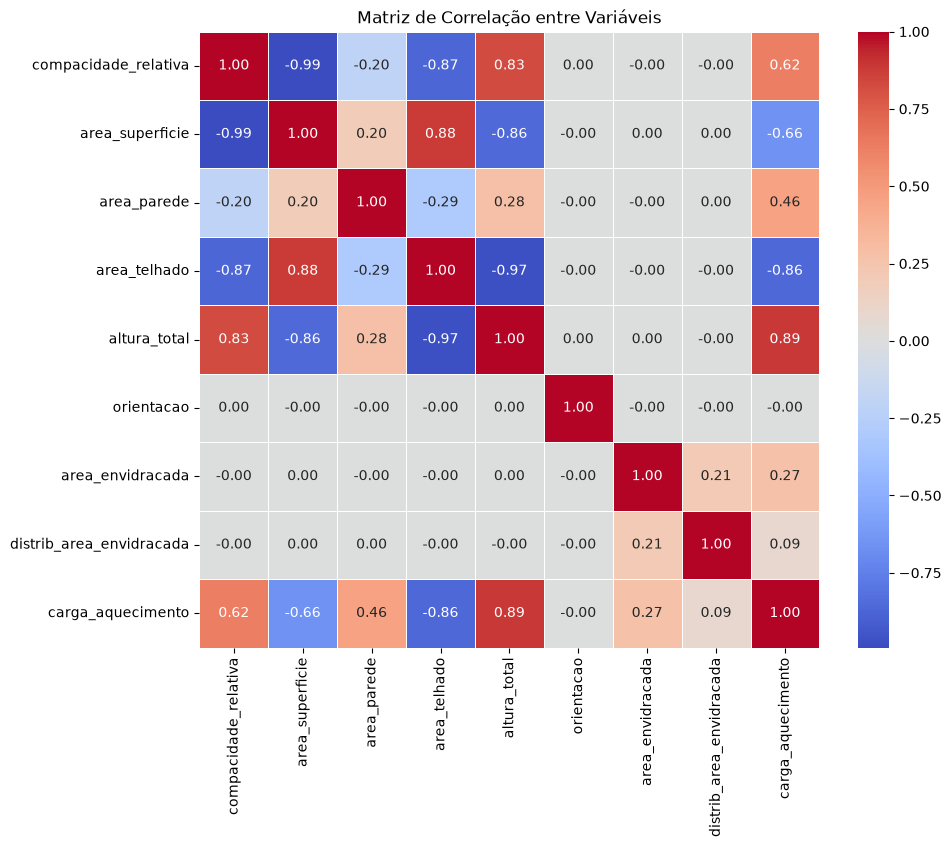

In [46]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlação entre Variáveis")
plt.show()


# Se a celula (x,y) for proxima de 1, significa que as features x e y proporcionais
# Se a celula (x,y) for proxima de -1, significa que as features x e y inversamente proporcionais
# Se a celula (x,y) for proxima de 0, significa que as features x e y nao tem relaçao

Precisamos separar as features do target, e também separar uma parte dos dados para treinar o modelo e outra para testar/validar.

vou usar 20% para teste e 80% para treino   

In [48]:
from sklearn.model_selection import train_test_split

In [49]:
X = df.drop(columns=['carga_aquecimento'])
y = df['carga_aquecimento']

# Vamos manter um random_state fixo para reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [50]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [52]:
model_raw = LinearRegression()
model_raw.fit(X_train, y_train)
pred_raw = model_raw.predict(X_test)

print("--- DESEMPENHO MODELO RAW (SEM TRATAMENTO) ---")
print(f"R²:  {r2_score(y_test, pred_raw):.4f}")
print(f"MAE: {mean_absolute_error(y_test, pred_raw):.4f}")
print(f"MSE: {mean_squared_error(y_test, pred_raw):.4f}\n")


--- DESEMPENHO MODELO RAW (SEM TRATAMENTO) ---
R²:  0.9122
MAE: 2.1820
MSE: 9.1532



In [54]:
from sklearn.preprocessing import StandardScaler

In [ ]:
# criando o normalizador
scaler = StandardScaler()


# fit -> objeto do normalziador aprende, transform ele transforma os dados
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Criando e treinando o modelo com os dados normalizados
model_norm = LinearRegression()
model_norm.fit(X_train_scaled, y_train)
pred_norm = model_norm.predict(X_test_scaled)

print("--- DESEMPENHO MODELO NORMALIZADO ---")
print(f"R²:  {r2_score(y_test, pred_norm):.4f}")
print(f"MAE: {mean_absolute_error(y_test, pred_norm):.4f}")
print(f"MSE: {mean_squared_error(y_test, pred_norm):.4f}\n")


--- DESEMPENHO MODELO NORMALIZADO ---
R²:  0.9122
MAE: 2.1820
MSE: 9.1532

